# Small example

In [1]:
import atmPy.file_io as atmfio

In [2]:
plt.rcParams['figure.dpi'] = 200

In [3]:
start = '2025-09-01'
start = '2026-07-12'
end = '2026-07-14'
site = 'sxf'

In [4]:
gen = atmfio.files_between(f'/Volumes/grad/surfrad/products_level2/radflux_rd/0.1/final/{site}/', 
                            start = start, end = end,                           
                           globpattern = '*{date:%Y%m%d}*'
                          )
dsrd = xr.open_mfdataset(gen)

In [5]:
gen = atmfio.files_between(f'/Volumes/grad/surfrad/products_level4/radflux/v1.0/{site}/', 
                            start = start, end = end,                           
                           globpattern = '*{date:%Y%m%d}*'
                          )
dsl = xr.open_mfdataset(gen)

dsl = dsl.rename({'time': 'datetime'})
dslri = dsl.reindex(datetime = dsrd.datetime, method='nearest', tolerance=pd.to_timedelta(60, 's'))



In [6]:
gen = atmfio.files_between('/Volumes/grad/surfrad/products_level1/radiation_netcdf/v1.1/tbl/', 
                            start = start, end = end,                           
                           globpattern = '*{date:%Y%m%d}*'
                          )
dsraw = xr.open_mfdataset(gen)

Text(0.5, 0, '')

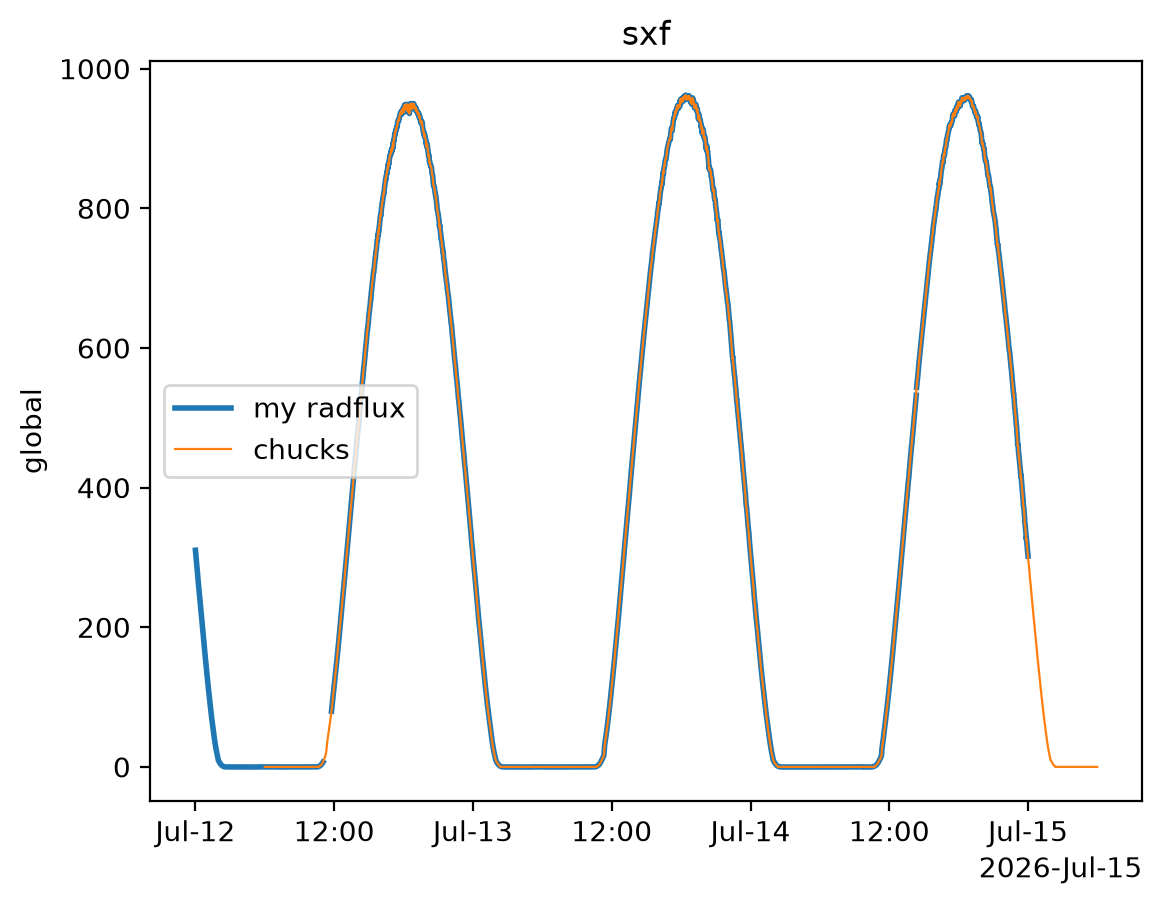

In [7]:
f,a = plt.subplots()
# dsrd.clearsky_global_horizontal.plot(ax =a)
# dsl.shortwave_down_clear_sky_estimate.plot(ax=a )
dsrd.global_horizontal.plot(ax =a, label = 'my radflux', lw = 2)
dsl.shortwave_down_best_estimate.plot(ax = a, label = 'chucks', lw = 0.8) 
a.legend()
a.set_title(site)
a.set_ylabel('global')
a.set_xlabel('')

Text(0.5, 0, '')

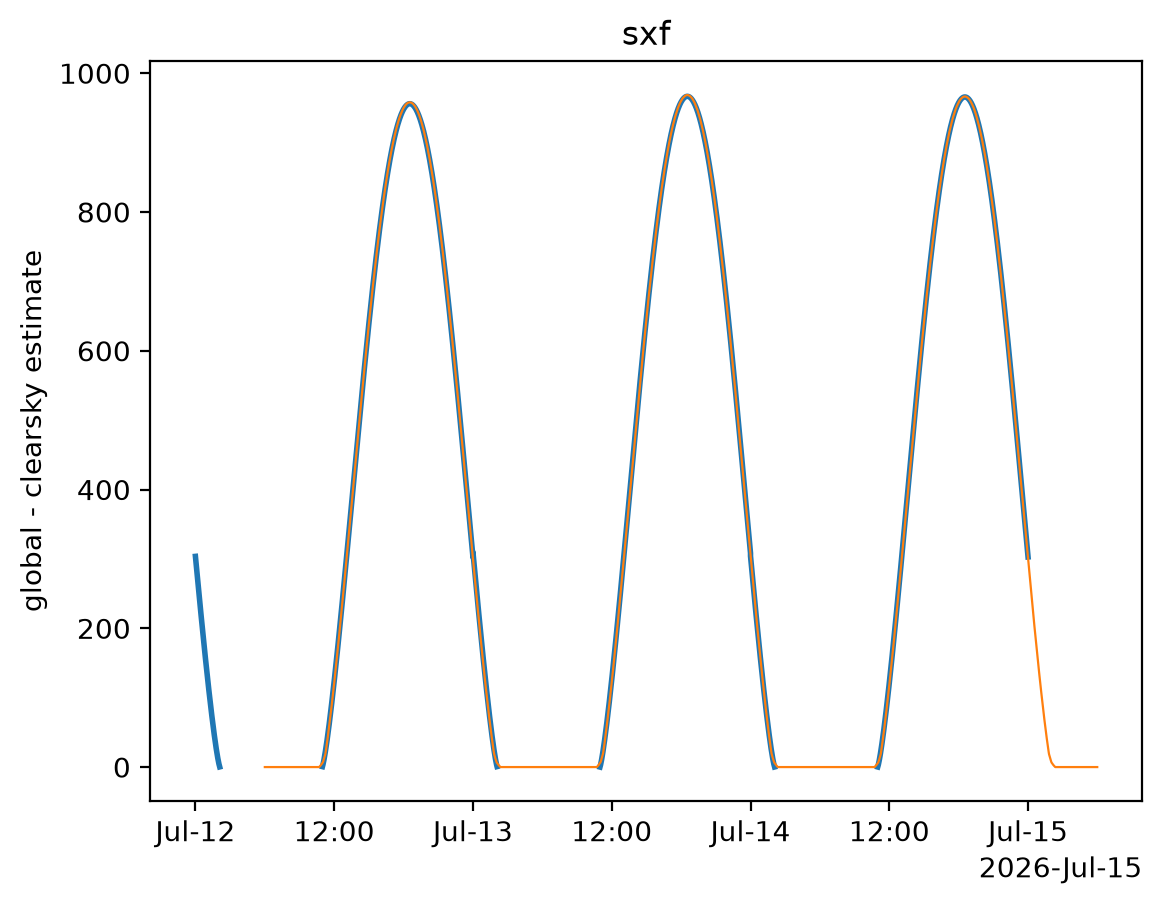

In [8]:
f,a = plt.subplots()
dsrd.clearsky_global_horizontal.plot(ax =a, label = 'my radflux', lw = 2)
dsl.shortwave_down_clear_sky_estimate.plot(ax = a, label = 'chucks', lw = 0.8) 
a.set_title(site)
a.set_ylabel('global - clearsky estimate')
a.set_xlabel('')

Text(0.5, 0, '')

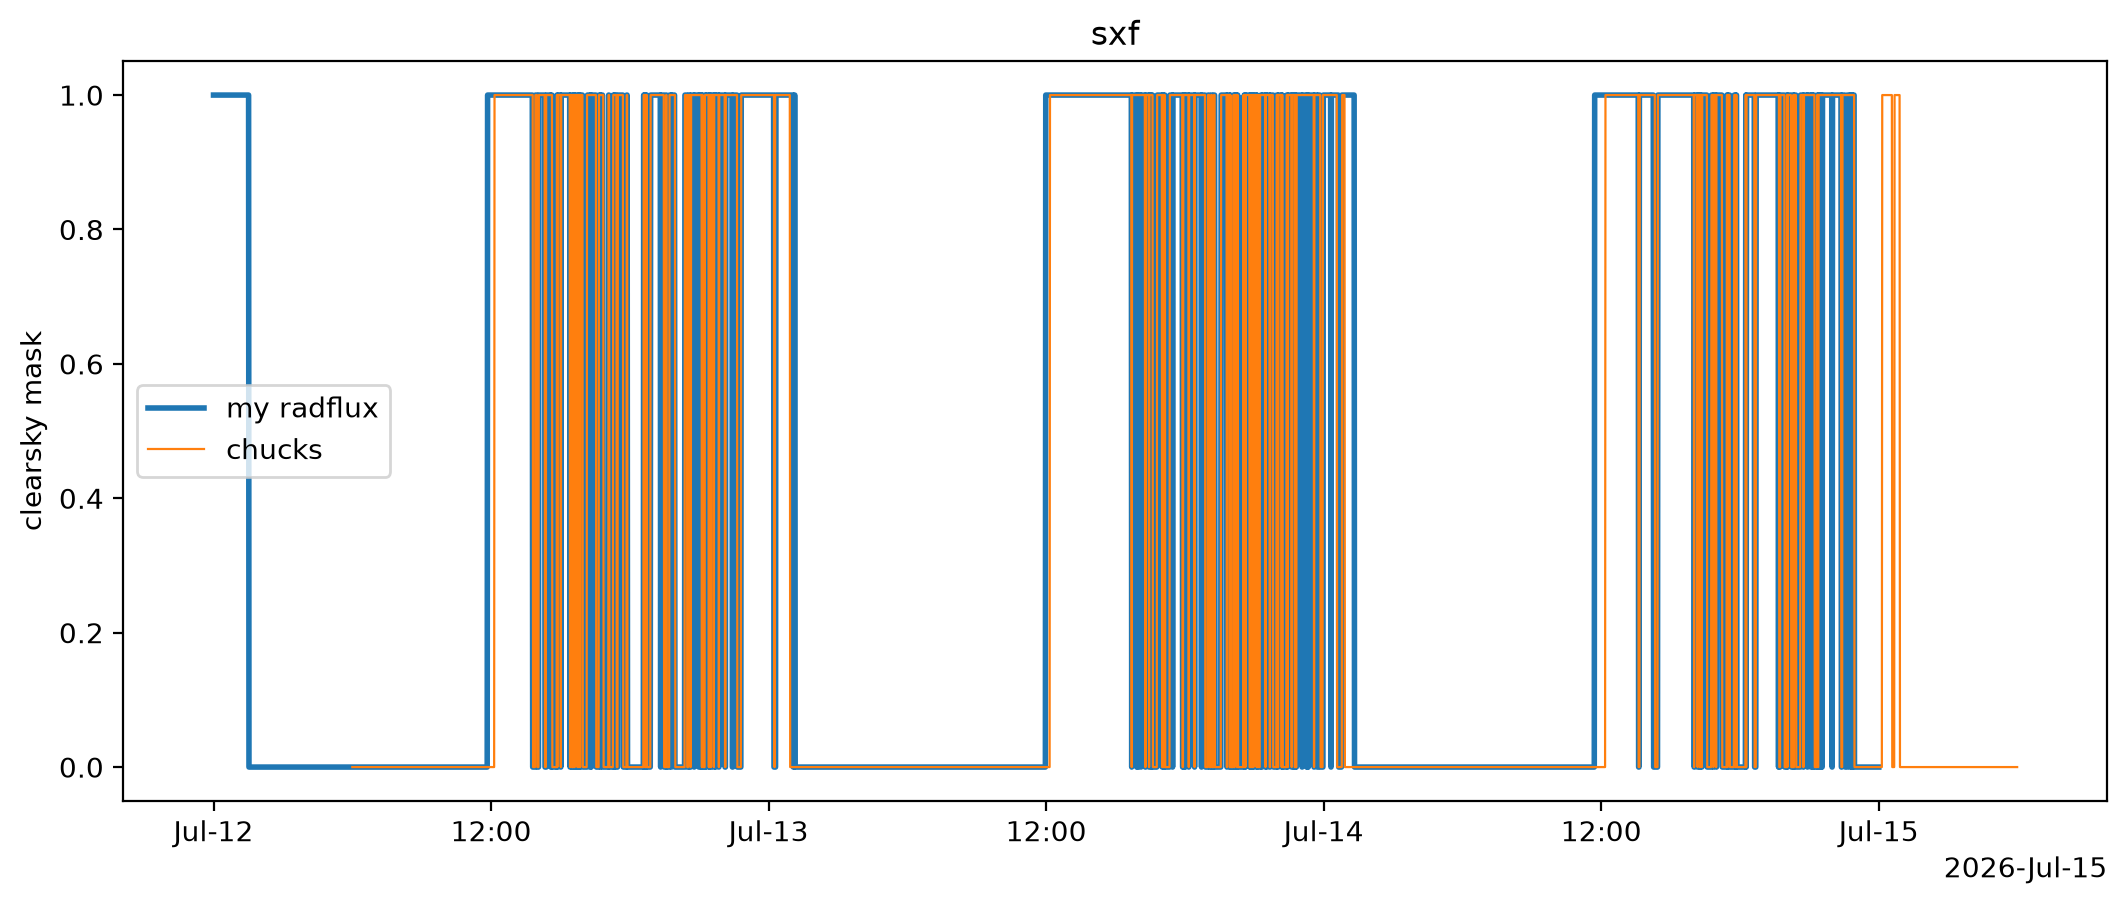

In [9]:
f,a = plt.subplots()
f.set_figwidth(f.get_figwidth() * 2)

dsrd.mask_clear_sky_shortwave.plot(ax =a, label = 'my radflux', lw = 2)
dsl.flag_clear_sky.where(dsl.flag_clear_sky <= 1, other = 0).plot(ax = a, label = 'chucks', lw = 0.8) 
a.legend()
a.set_title(site)
a.set_ylabel('clearsky mask')
a.set_xlabel('')

Text(0.5, 0, '')

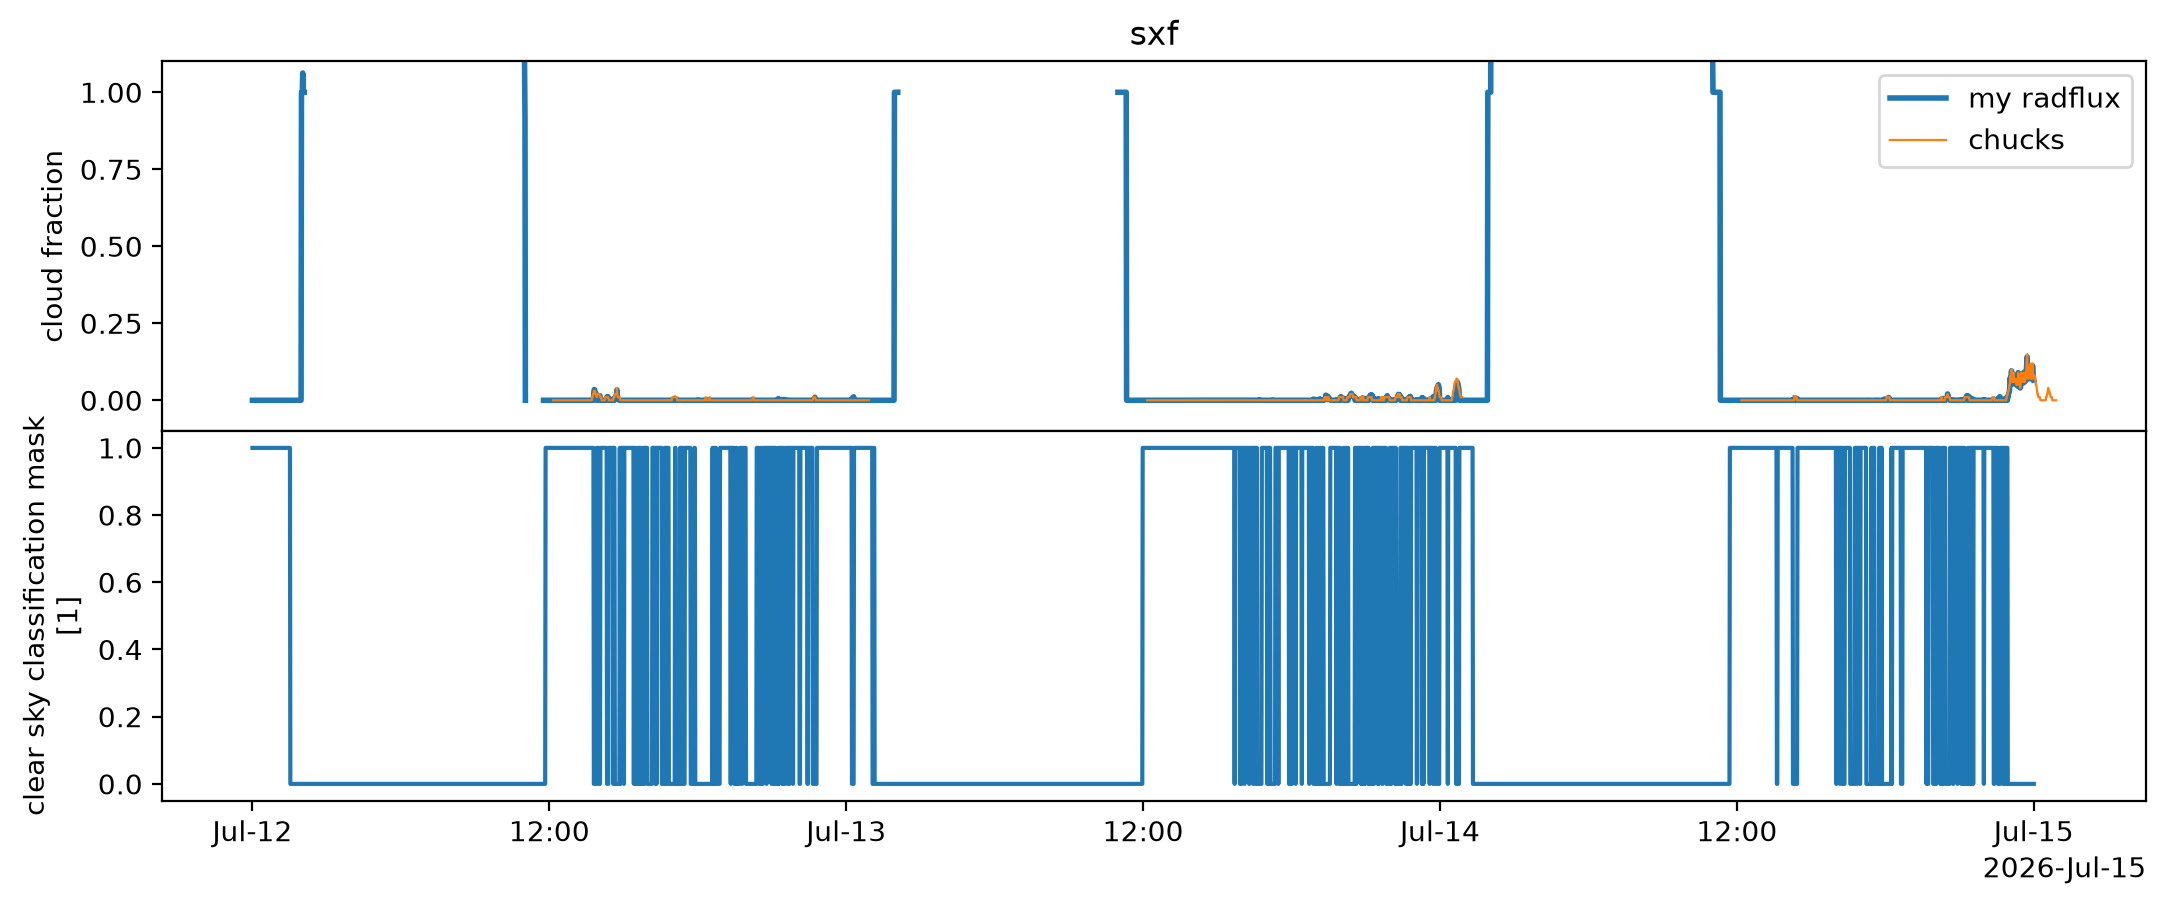

In [10]:
f,aa = plt.subplots(2, sharex=True, gridspec_kw={'hspace':0})
f.set_figwidth(f.get_figwidth() * 2)
a = aa[0]
dsrd.shortwave_cloud_fraction.plot(ax =a, label = 'my radflux', lw = 2)
dsl.sky_cover_shortwave.plot(ax = a, label = 'chucks', lw = 0.8) 
a.legend()
a.set_ylim(-0.1,1.1)
a.set_title(site)
a.set_ylabel('cloud fraction')

a = aa[1]
dsrd.mask_clear_sky_shortwave.plot(ax =a, label = 'my radflux', 
                                   # lw = 2
                                  )


a.set_xlabel('')

# Overview and statistics

In [11]:
import atmPy.file_io as atmfio

In [12]:
plt.rcParams['figure.dpi'] = 200

In [13]:
reload(atmfio)

<module 'atmPy.file_io' from '/Users/htelg/prog/atm-py/atmPy/file_io.py'>

In [14]:
start = '2025-09-01'
# start = '2026-08-01'
end = '2026-09-01'

In [15]:
gen = atmfio.files_between(f'/Volumes/grad/surfrad/products_level2/radflux_rd/0.1/final/{site}/', 
                            start = start, end = end,                           
                           globpattern = '*{date:%Y%m%d}*'
                          )
dsrd = xr.open_mfdataset(gen)

In [16]:
gen = atmfio.files_between(f'/Volumes/grad/surfrad/products_level4/radflux/v1.0/{site}/', 
                            start = start, end = end,                           
                           globpattern = '*{date:%Y%m%d}*'
                          )
dsl = xr.open_mfdataset(gen)

dsl = dsl.rename({'time': 'datetime'})
dslri = dsl.reindex(datetime = dsrd.datetime, method='nearest', tolerance=pd.to_timedelta(60, 's'))



Text(0.5, 0, '')

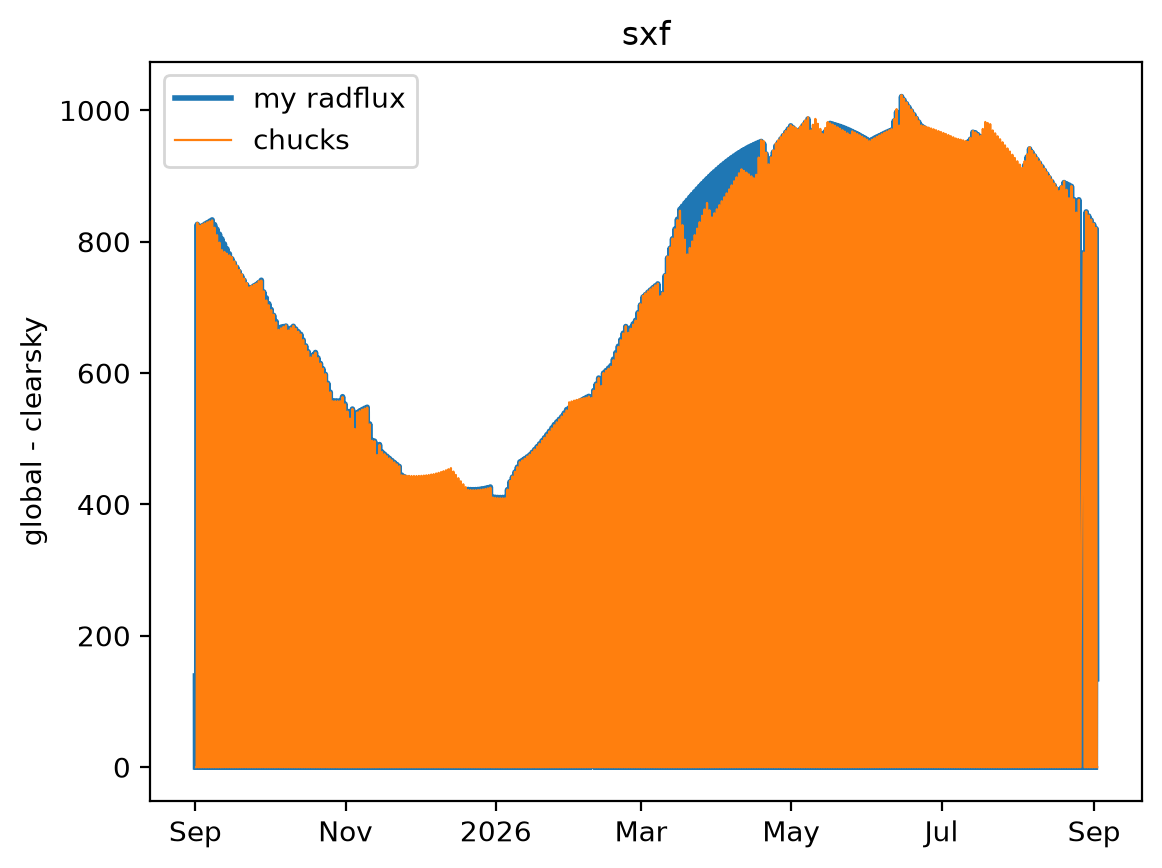

In [17]:
f,a = plt.subplots()
# dsrd.clearsky_global_horizontal.plot(ax =a)
# dsl.shortwave_down_clear_sky_estimate.plot(ax=a )
dsrd.clearsky_global_horizontal.plot(ax =a, label = 'my radflux', lw = 2)
dsl.shortwave_down_clear_sky_estimate.plot(ax = a, label = 'chucks', lw = 0.8) 
a.legend()
a.set_title(site)
a.set_ylabel('global - clearsky')
a.set_xlabel('')

Text(0.5, 0, '')

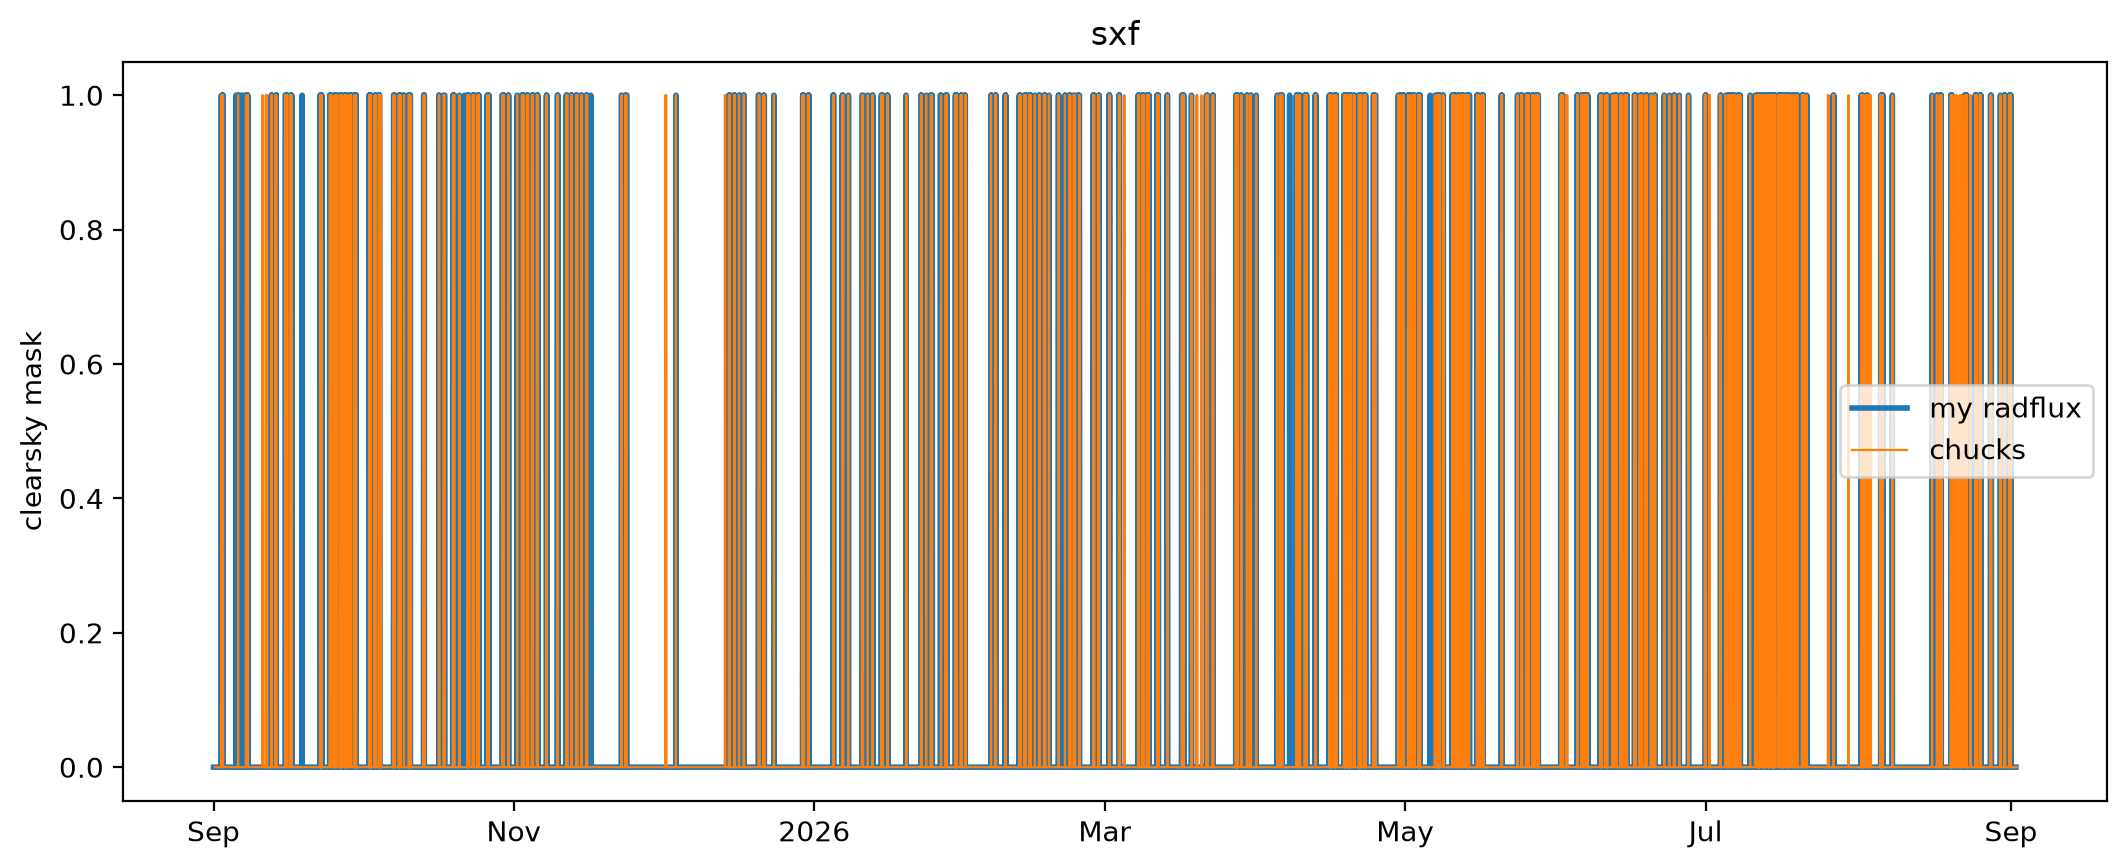

In [18]:
f,a = plt.subplots()
f.set_figwidth(f.get_figwidth() * 2)

dsrd.mask_clear_sky_shortwave.plot(ax =a, label = 'my radflux', lw = 2)
dsl.flag_clear_sky.where(dsl.flag_clear_sky <= 1, other = 0).plot(ax = a, label = 'chucks', lw = 0.8) 
a.legend()
a.set_title(site)
a.set_ylabel('clearsky mask')
a.set_xlabel('')

Text(0.5, 0, '')

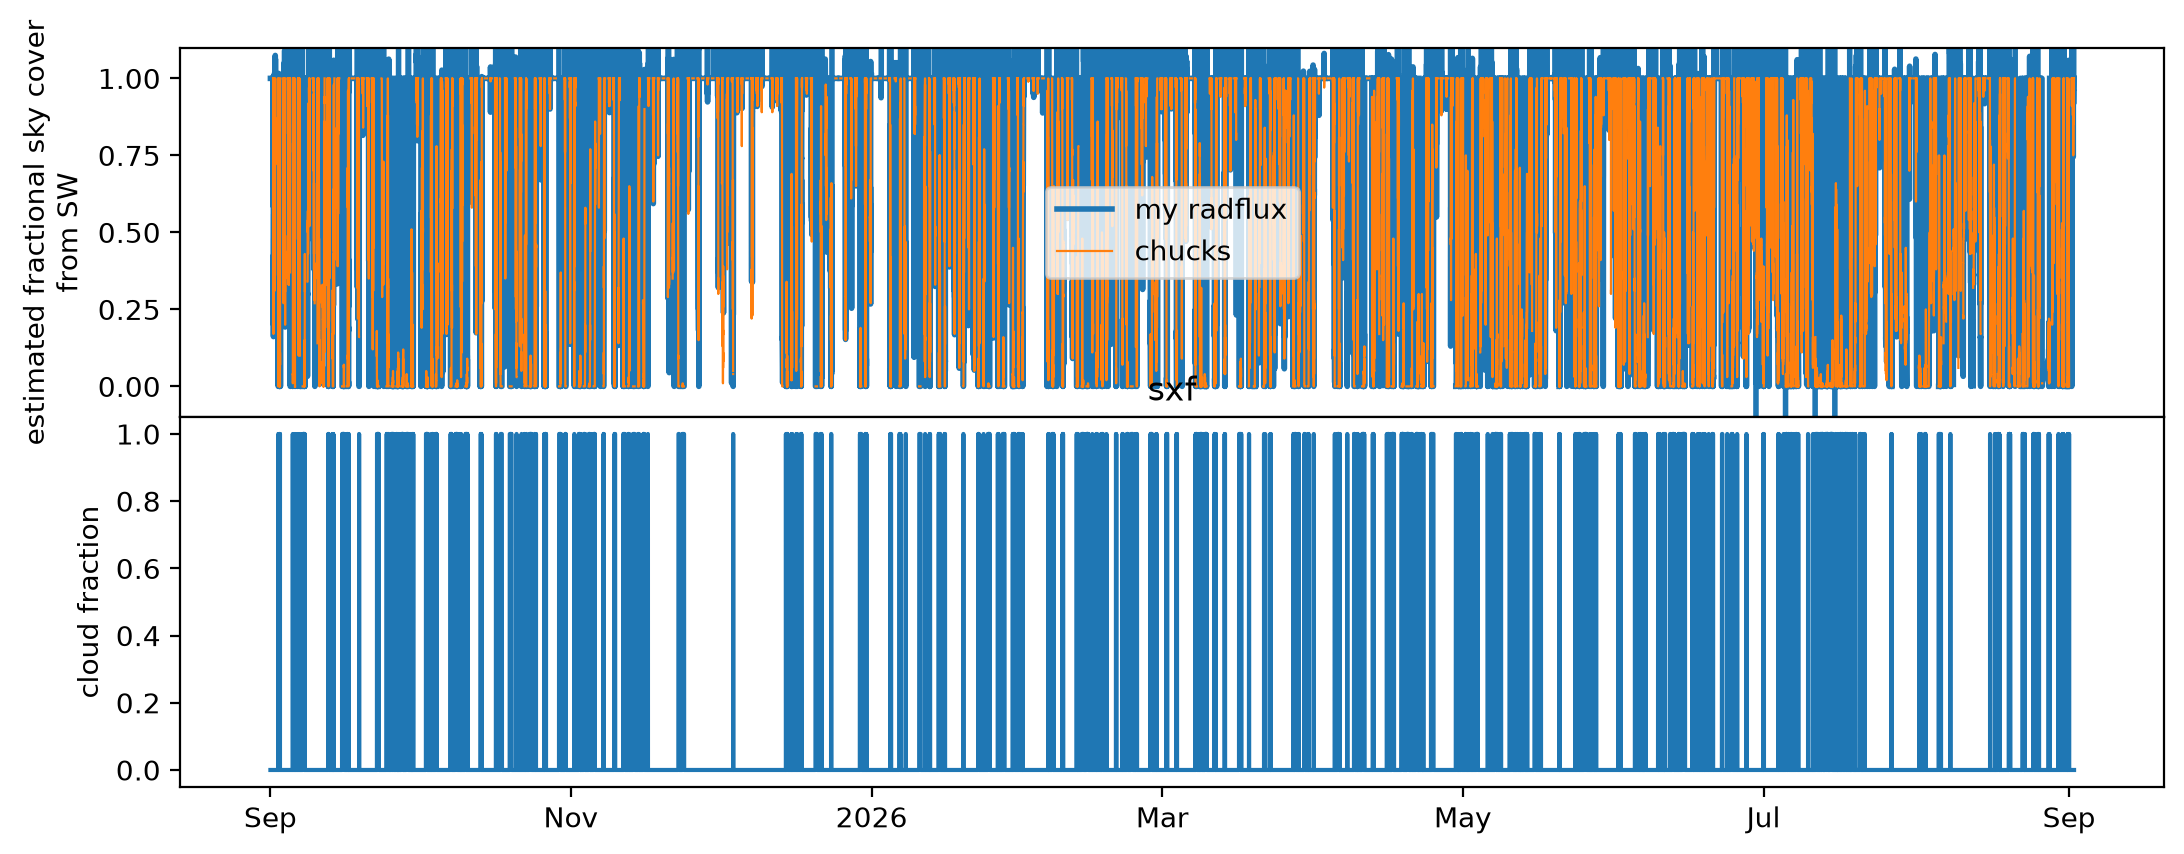

In [19]:
f,aa = plt.subplots(2, sharex=True, gridspec_kw={'hspace':0})
f.set_figwidth(f.get_figwidth() * 2)
a = aa[0]
dsrd.shortwave_cloud_fraction.plot(ax =a, label = 'my radflux', lw = 2)
dsl.sky_cover_shortwave.plot(ax = a, label = 'chucks', lw = 0.8) 
a.legend()
a.set_ylim(-0.1,1.1)

a = aa[1]
dsrd.mask_clear_sky_shortwave.plot(ax =a, label = 'my radflux', 
                                   # lw = 2
                                  )

a.set_title(site)
a.set_ylabel('cloud fraction')
a.set_xlabel('')

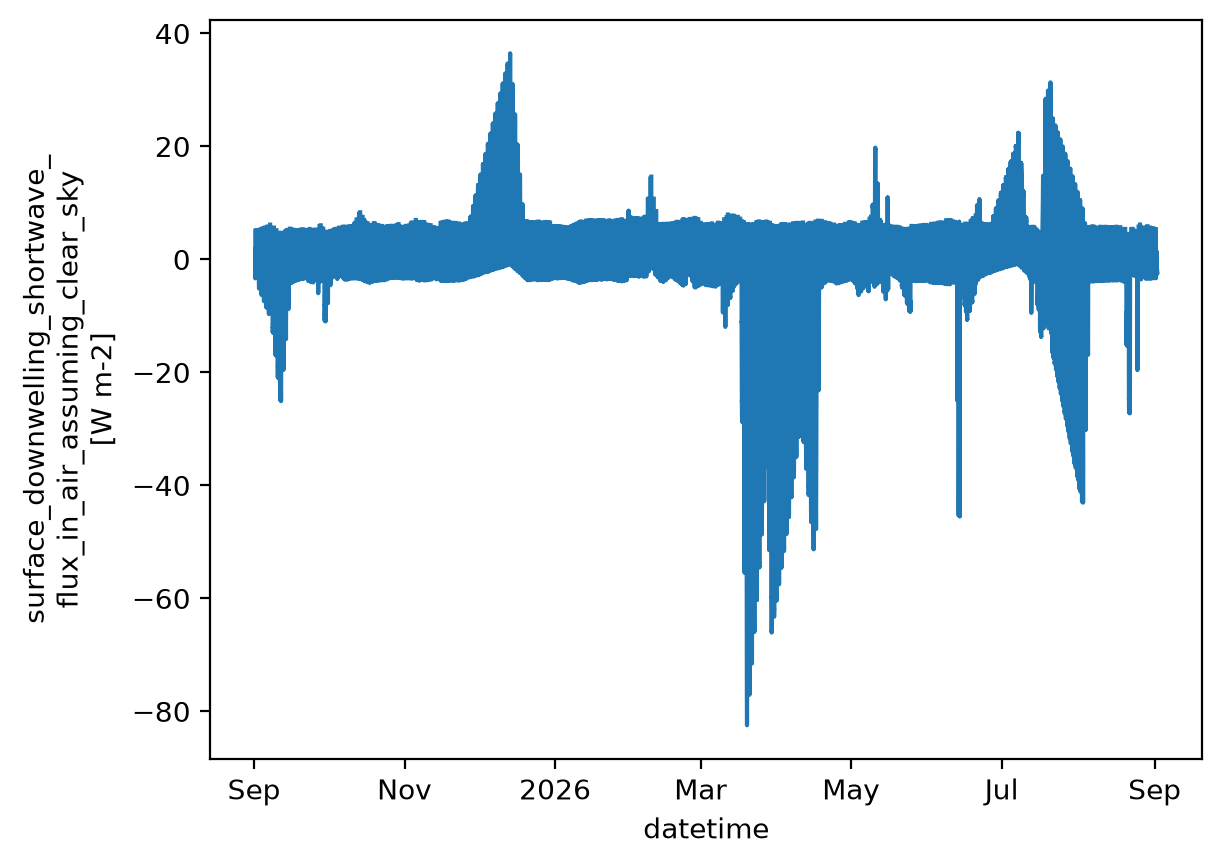

In [20]:
(dslri.shortwave_down_clear_sky_estimate - dsrd.clearsky_global_horizontal).plot()

(0.9, 1.1)

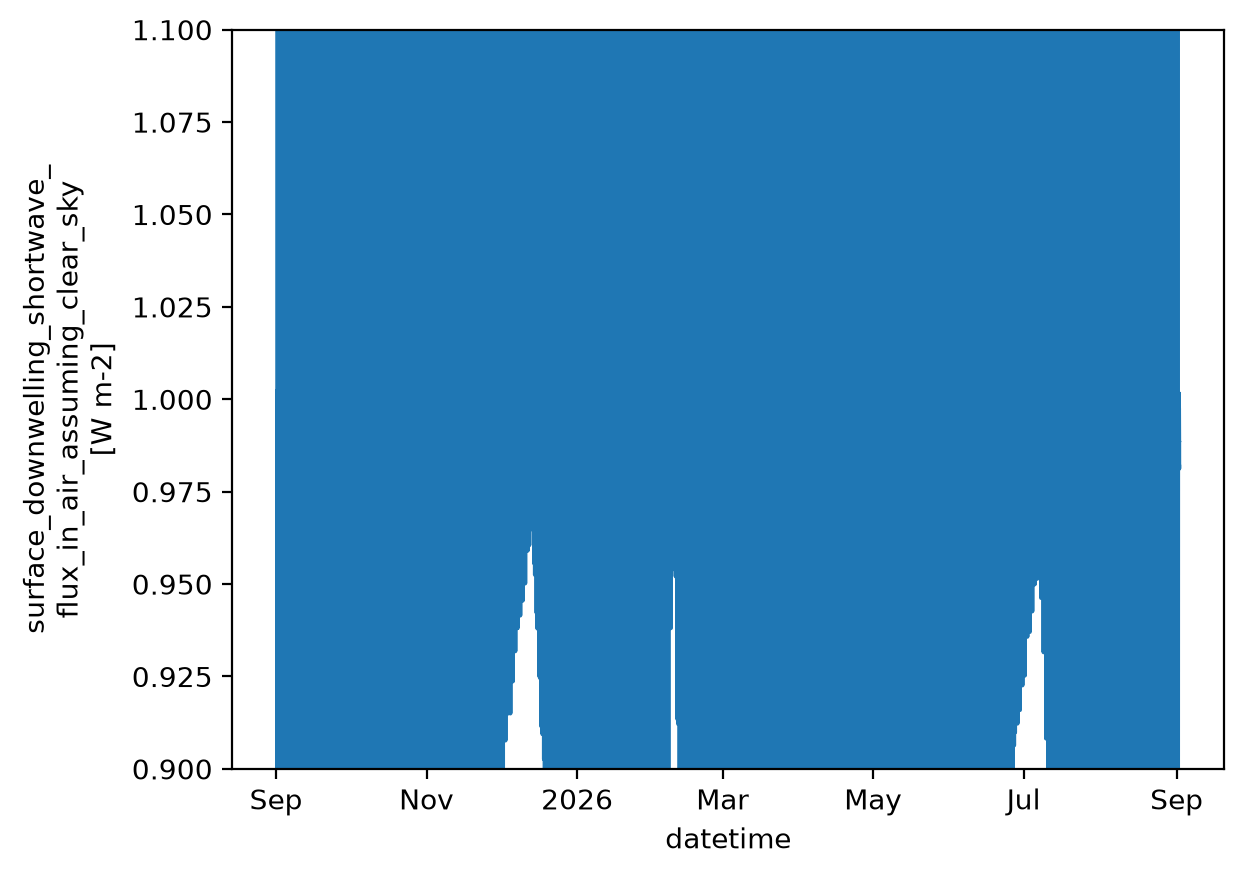

In [21]:
f,a = plt.subplots()
(dslri.shortwave_down_clear_sky_estimate / dsrd.clearsky_global_horizontal).plot(ax = a)
a.set_ylim(0.9, 1.1)

In [22]:
dsrd["shortwave_cloud_fraction"] = dsrd.shortwave_cloud_fraction.where(dsrd.shortwave_cloud_fraction <= 1, other = 1)

In [23]:
import atmPy.general.timeseries as atmts

In [24]:
tsl = atmts.TimeSeries(dslri.shortwave_down_clear_sky_estimate.to_dataframe())
                 # - dsrd.clearsky_global_horizontal

In [25]:
tsrd = atmts.TimeSeries(dsrd.clearsky_global_horizontal.to_dataframe())


In [26]:
corr = tsl.correlate_to(tsrd)

Text(0.5, 0, "Chucks's")

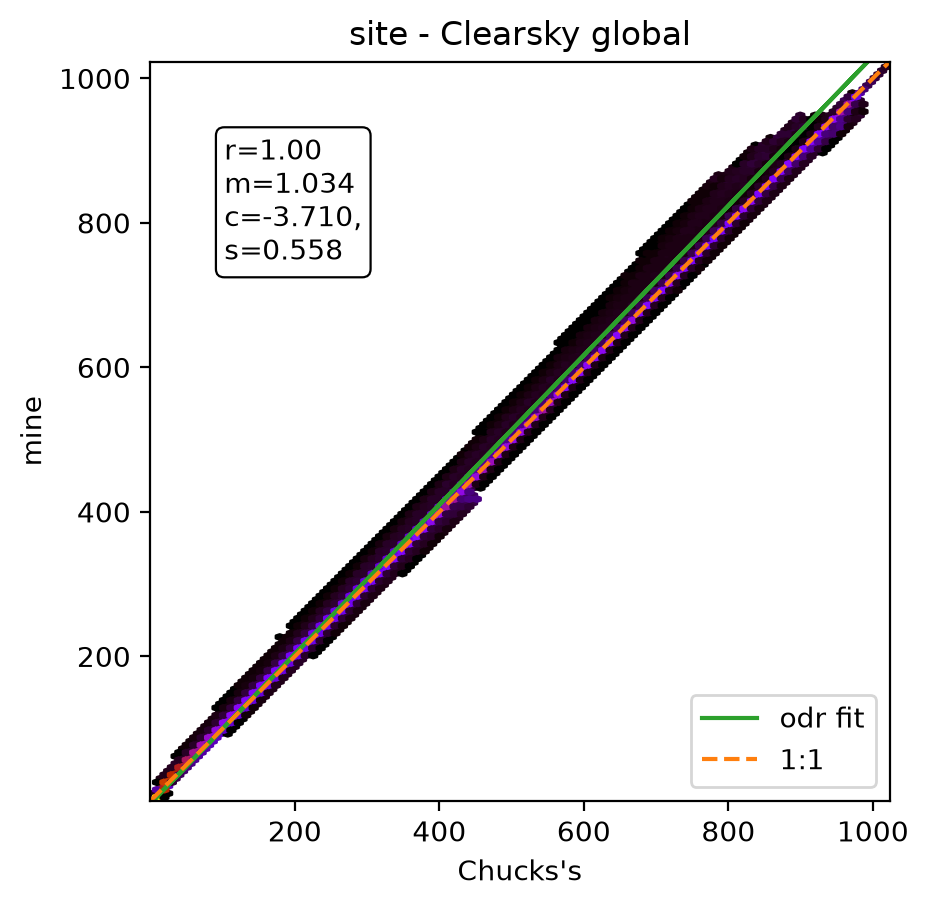

In [27]:
out = corr.plot_regression()
a = out[0]
a.set_title(f'site - Clearsky global')
a.set_ylabel('mine')
a.set_xlabel("Chucks's")

(-0.1, 1.1)

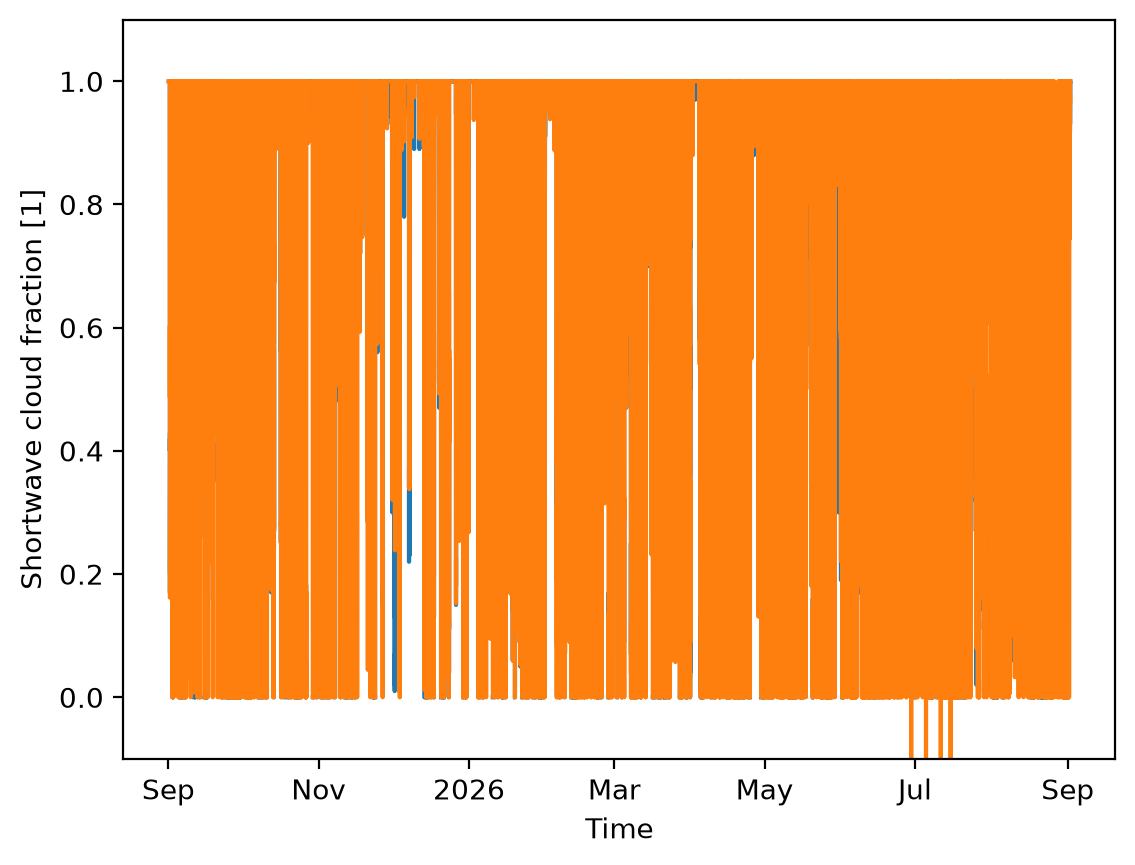

In [28]:
f,a = plt.subplots()
dslri.sky_cover_shortwave.plot(ax = a)
dsrd.shortwave_cloud_fraction.plot(ax = a)
a.set_ylim(-0.1, 1.1)

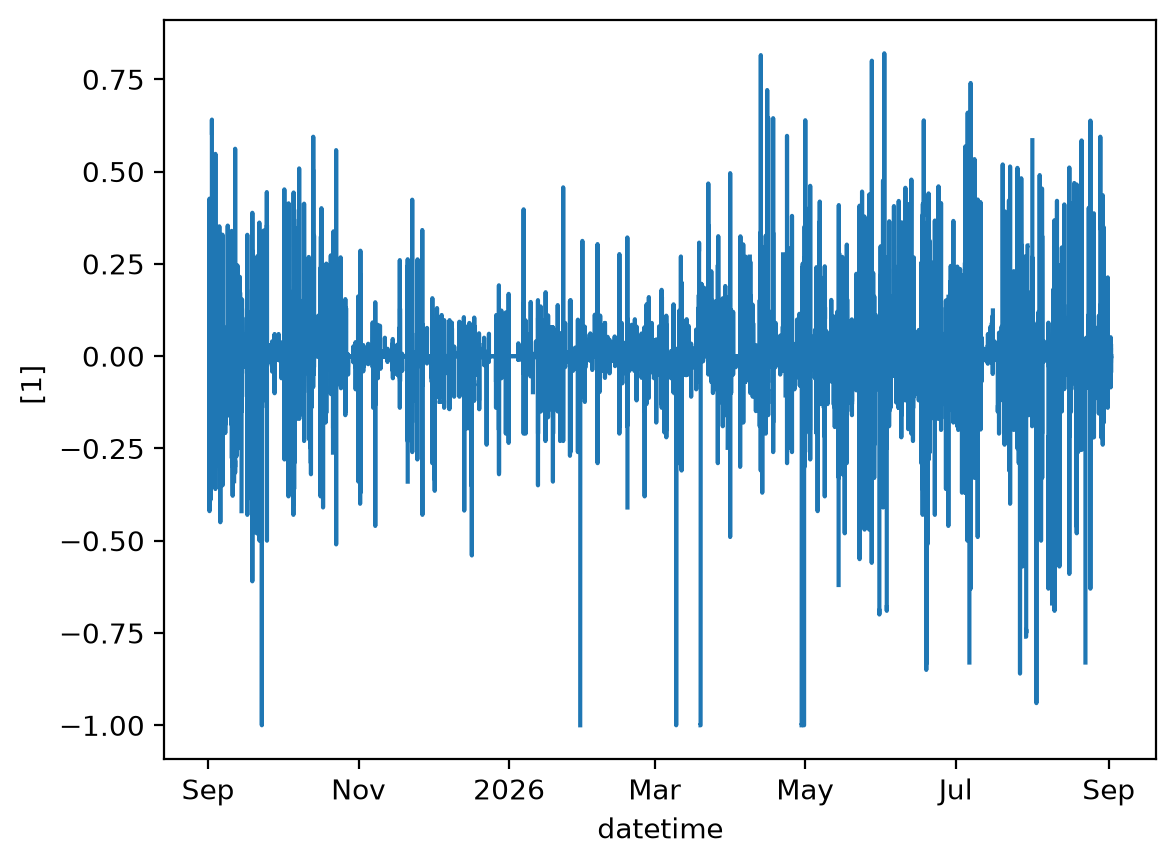

In [29]:
f,a = plt.subplots()
(dslri.sky_cover_shortwave - dsrd.shortwave_cloud_fraction).plot(ax = a)
# a.set_ylim(-0.1, 1.1)

Text(0.5, 0, "Chucks's")

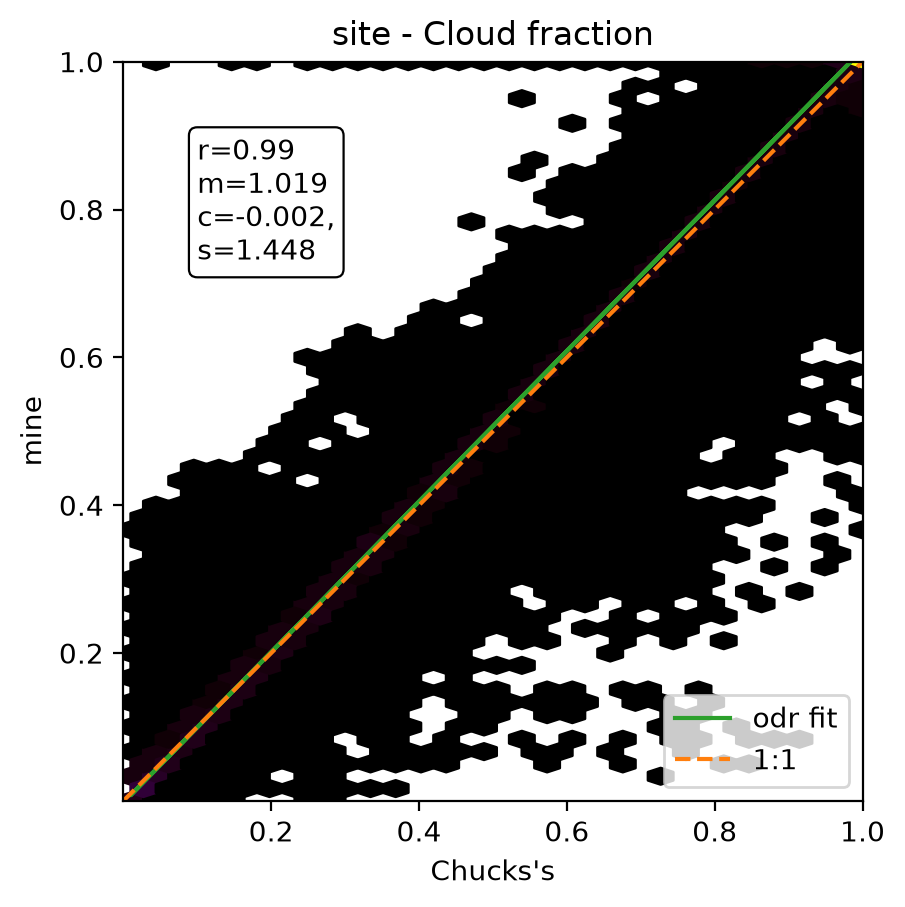

In [30]:
where = (dslri.sky_cover_shortwave <= 1) & (dslri.sky_cover_shortwave >= 0)
tsl = atmts.TimeSeries(dslri.sky_cover_shortwave.where(where).to_dataframe())
                 # - dsrd.clearsky_global_horizontal

where = (dsrd.shortwave_cloud_fraction <= 1) & (dsrd.shortwave_cloud_fraction >= 0)
tsrd = atmts.TimeSeries(dsrd.shortwave_cloud_fraction.where(where).to_dataframe())


corr = tsl.correlate_to(tsrd)

out = corr.plot_regression(#xlim = (0,1), ylim = (0,1), 
                     gridsize=30)
a = out[0]
a.set_title(f'site - Cloud fraction')
a.set_ylabel('mine')
a.set_xlabel("Chucks's")

Text(0.5, 47.77777777777777, "Chucks's")

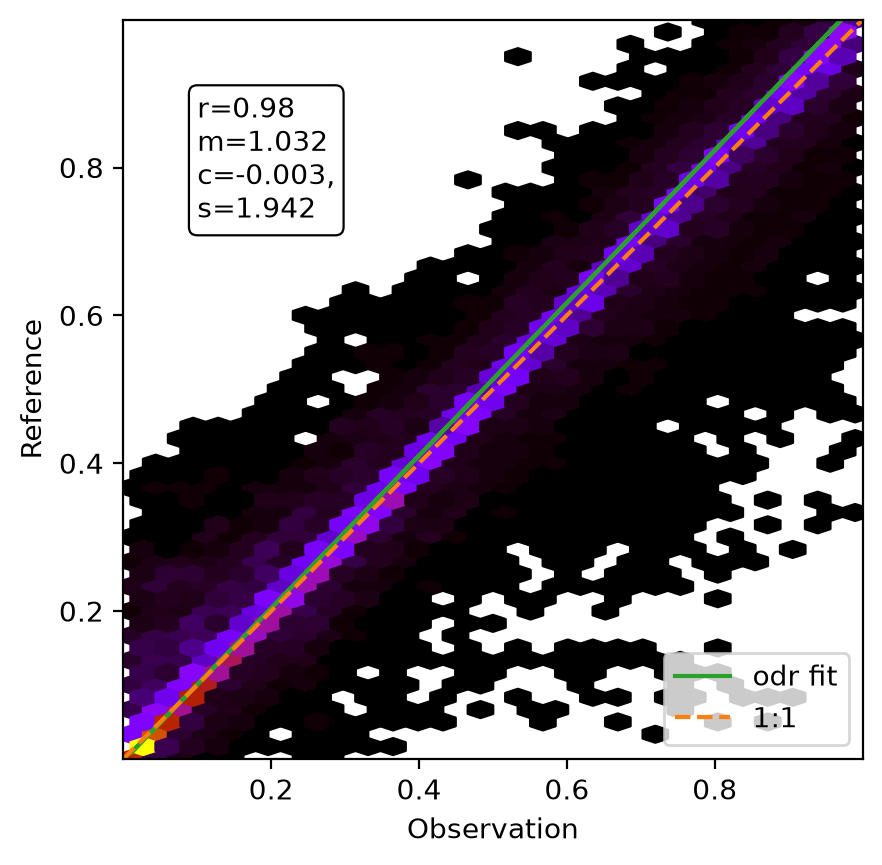

In [31]:
where = (dslri.sky_cover_shortwave < 1) & (dslri.sky_cover_shortwave > 0)
tsl = atmts.TimeSeries(dslri.sky_cover_shortwave.where(where).to_dataframe())
                 # - dsrd.clearsky_global_horizontal

where = (dsrd.shortwave_cloud_fraction < 1) & (dsrd.shortwave_cloud_fraction > 0)
tsrd = atmts.TimeSeries(dsrd.shortwave_cloud_fraction.where(where).to_dataframe())


corr = tsl.correlate_to(tsrd)

corr.plot_regression(#xlim = (0,1), ylim = (0,1), 
                     gridsize=30)
a = out[0]
a.set_title(f'site - Cloud fraction, wo 1 and 0')
a.set_ylabel('mine')
a.set_xlabel("Chucks's")

Text(0.5, 47.77777777777777, "Chucks's")

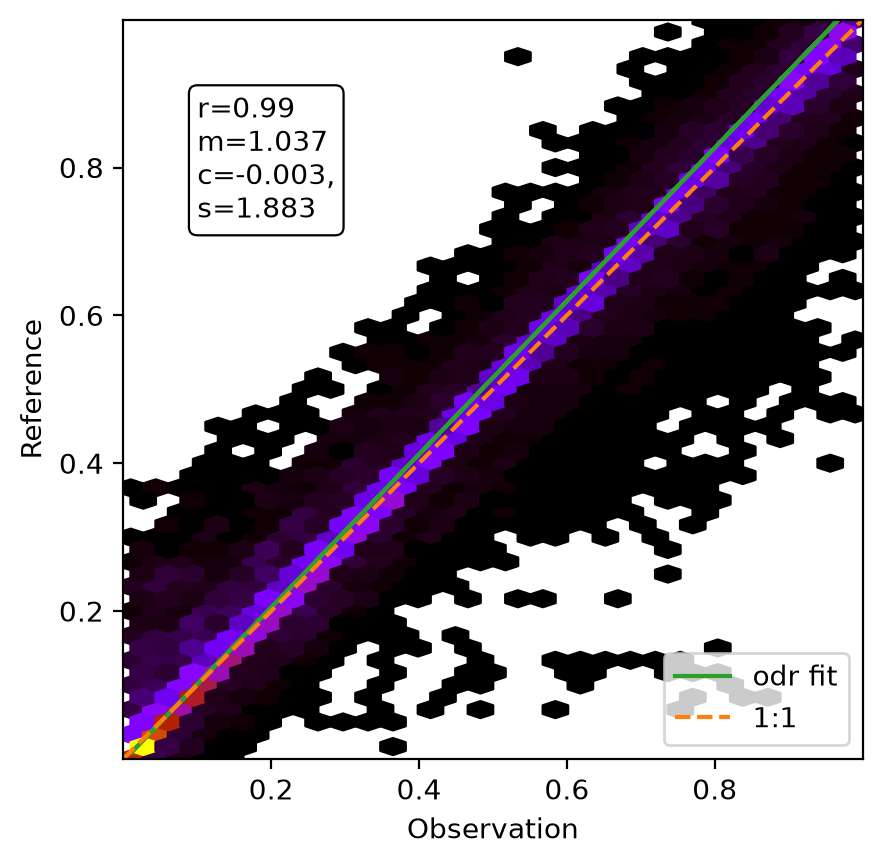

In [32]:
szalim = 70
where = (dslri.sky_cover_shortwave < 1) & (dslri.sky_cover_shortwave > 0) & (dslri.solar_zenith_angle < szalim)
tsl = atmts.TimeSeries(dslri.sky_cover_shortwave.where(where).to_dataframe())
                 # - dsrd.clearsky_global_horizontal

where = (dsrd.shortwave_cloud_fraction < 1) & (dsrd.shortwave_cloud_fraction > 0) & (np.rad2deg(dsrd.solar_zenith) < szalim)
tsrd = atmts.TimeSeries(dsrd.shortwave_cloud_fraction.where(where).to_dataframe())


corr = tsl.correlate_to(tsrd)

corr.plot_regression(#xlim = (0,1), ylim = (0,1), 
                     gridsize=30)
a = out[0]
a.set_title(f'site - Cloud fraction, wo 1 and 0, z < 70deg')
a.set_ylabel('mine')
a.set_xlabel("Chucks's")

Text(0.5, 47.77777777777777, "Chucks's")

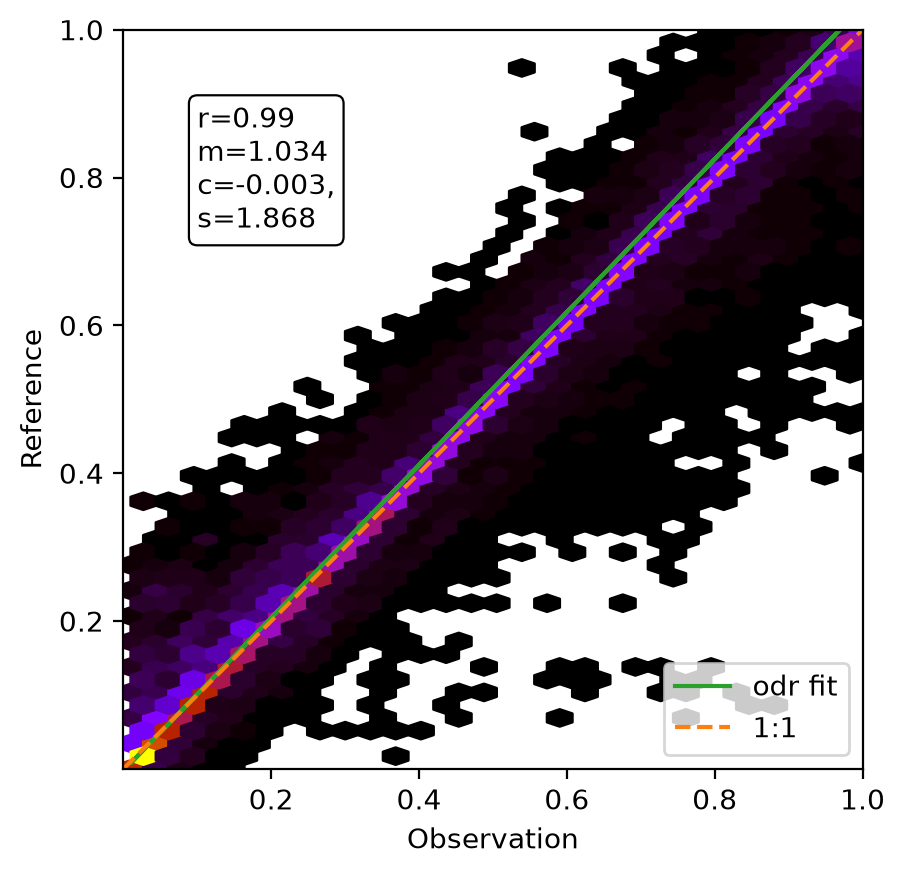

In [33]:
szalim = 70
where = (dslri.sky_cover_shortwave <= 1) & (dslri.sky_cover_shortwave >= 0) & (dslri.solar_zenith_angle < szalim)
tsl = atmts.TimeSeries(dslri.sky_cover_shortwave.where(where).to_dataframe())
                 # - dsrd.clearsky_global_horizontal

where = (dsrd.shortwave_cloud_fraction < 1) & (dsrd.shortwave_cloud_fraction > 0) & (np.rad2deg(dsrd.solar_zenith) < szalim)
tsrd = atmts.TimeSeries(dsrd.shortwave_cloud_fraction.where(where).to_dataframe())


corr = tsl.correlate_to(tsrd)

corr.plot_regression(#xlim = (0,1), ylim = (0,1), 
                     gridsize=30)
a = out[0]
a.set_title(f'site - Cloud fraction, za < 70deg')
a.set_ylabel('mine')
a.set_xlabel("Chucks's")

In [34]:
diff = dslri.sky_cover_shortwave - dsrd.shortwave_cloud_fraction

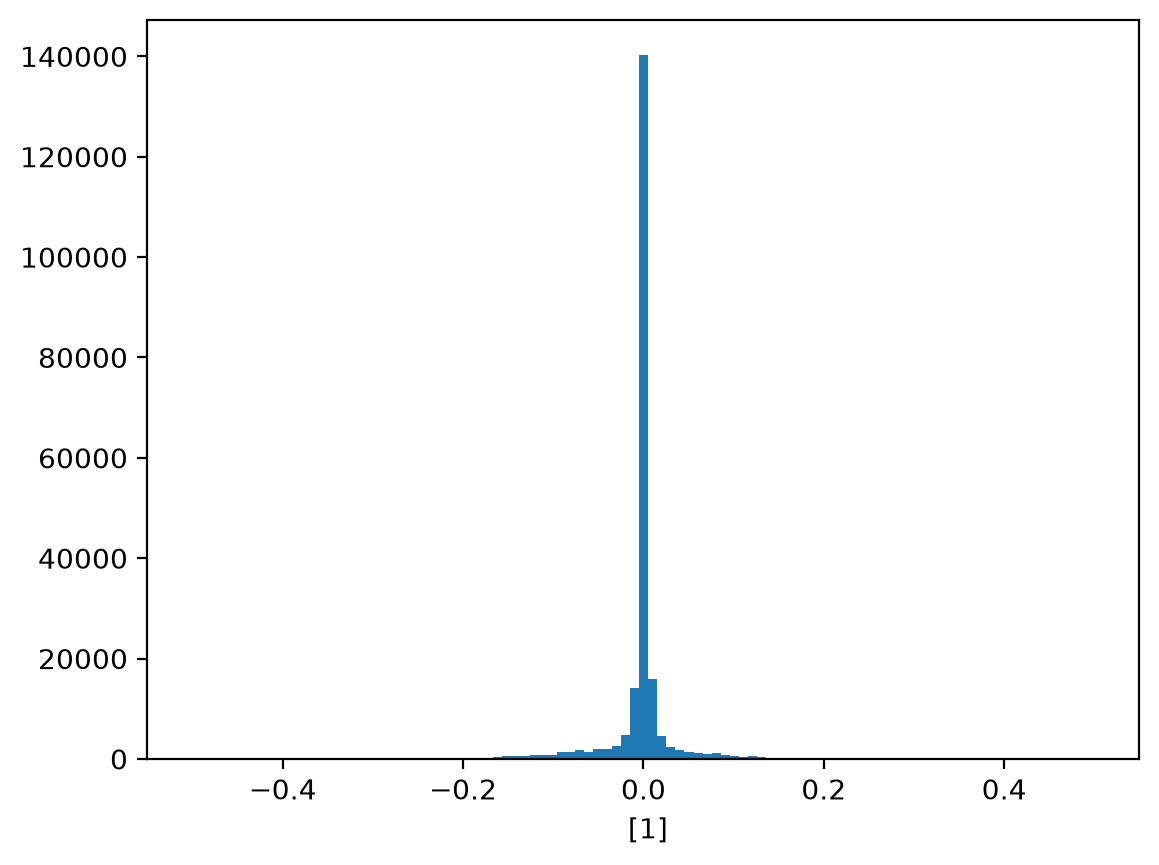

In [35]:
diff.plot.hist(bins = np.linspace(-0.5, 0.5, 100))
None

In [36]:
adiff = abs(diff).compute()

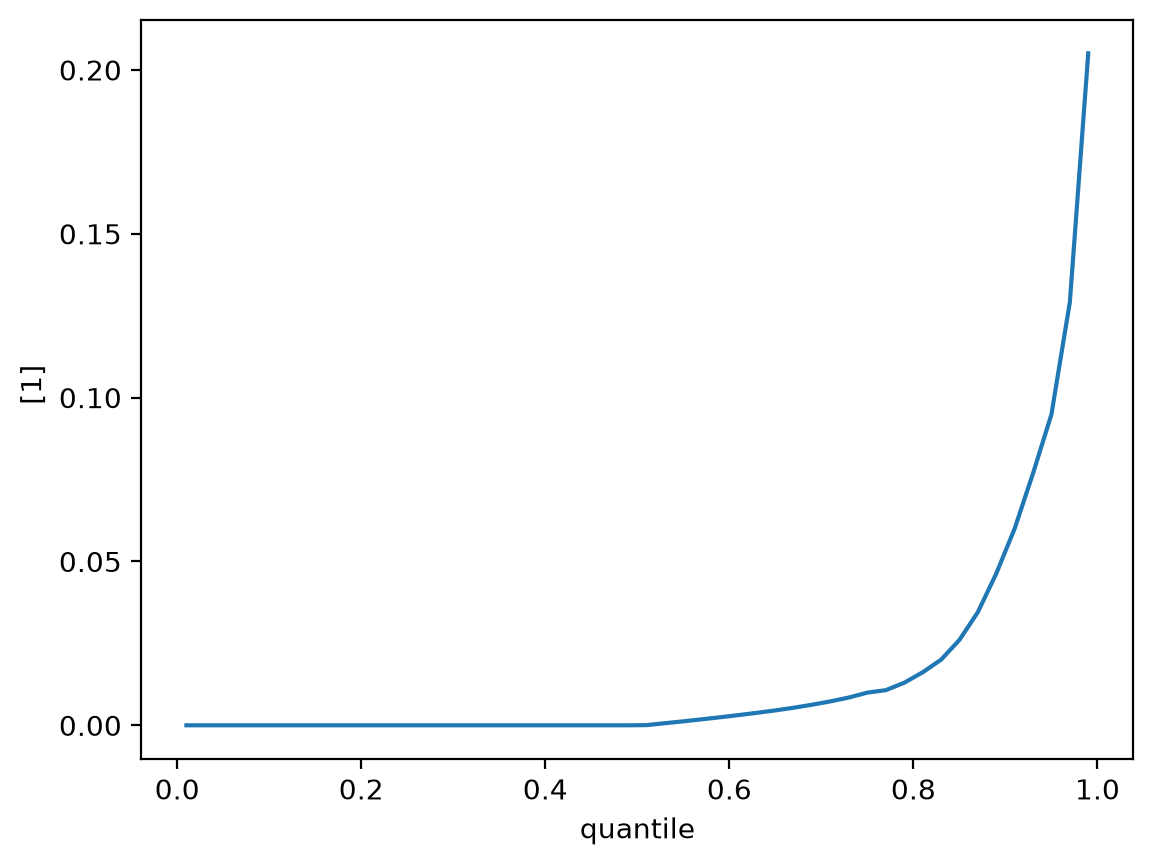

In [37]:
bla = adiff.quantile(np.linspace(0.01,0.99, 50), 'datetime')
bla.plot()

In [38]:
da = adiff
value = 0.1
q = (da <= value).sum() / da.notnull().sum()
q

<xarray.DataArray ()> Size: 8B
array(0.95423583)
Attributes:
    units:        1
    description:  Fractional sky cover retrieved from broadband shortwave rad...

In [39]:
# where = (dslri.sky_cover_shortwave < 1) & (dslri.sky_cover_shortwave > 0) & (dslri.solar_zenith_angle < szalim)
where = dslri.solar_zenith_angle < szalim
datl = dslri.sky_cover_shortwave.where(where)
                 # - dsrd.clearsky_global_horizontal

# where = (dsrd.shortwave_cloud_fraction < 1) & (dsrd.shortwave_cloud_fraction > 0) & (np.rad2deg(dsrd.solar_zenith) < szalim)
where = np.rad2deg(dsrd.solar_zenith) < szalim

datr = dsrd.shortwave_cloud_fraction.where(where)
diff = datl - datr

(array([4.00000e+00, 2.00000e+00, 1.00000e+00, 6.00000e+00, 3.00000e+00,
        2.00000e+00, 3.00000e+00, 2.00000e+00, 2.00000e+00, 3.00000e+00,
        4.00000e+00, 6.00000e+00, 5.00000e+00, 5.00000e+00, 8.00000e+00,
        7.00000e+00, 8.00000e+00, 1.00000e+01, 9.00000e+00, 1.20000e+01,
        1.30000e+01, 1.20000e+01, 3.70000e+01, 4.80000e+01, 5.00000e+01,
        7.60000e+01, 4.50000e+01, 9.50000e+01, 1.35000e+02, 1.92000e+02,
        2.09000e+02, 1.62000e+02, 2.05000e+02, 2.67000e+02, 3.58000e+02,
        3.55000e+02, 3.97000e+02, 4.85000e+02, 5.96000e+02, 6.28000e+02,
        1.12600e+03, 1.21300e+03, 1.49100e+03, 1.08400e+03, 1.63000e+03,
        1.70100e+03, 2.07000e+03, 4.22700e+03, 1.29410e+04, 1.11126e+05,
        1.34210e+04, 3.28100e+03, 1.79900e+03, 1.38600e+03, 1.03400e+03,
        9.01000e+02, 8.45000e+02, 8.53000e+02, 5.83000e+02, 3.88000e+02,
        2.81000e+02, 3.81000e+02, 2.22000e+02, 1.39000e+02, 1.27000e+02,
        9.30000e+01, 1.41000e+02, 1.16000e+02, 8.70

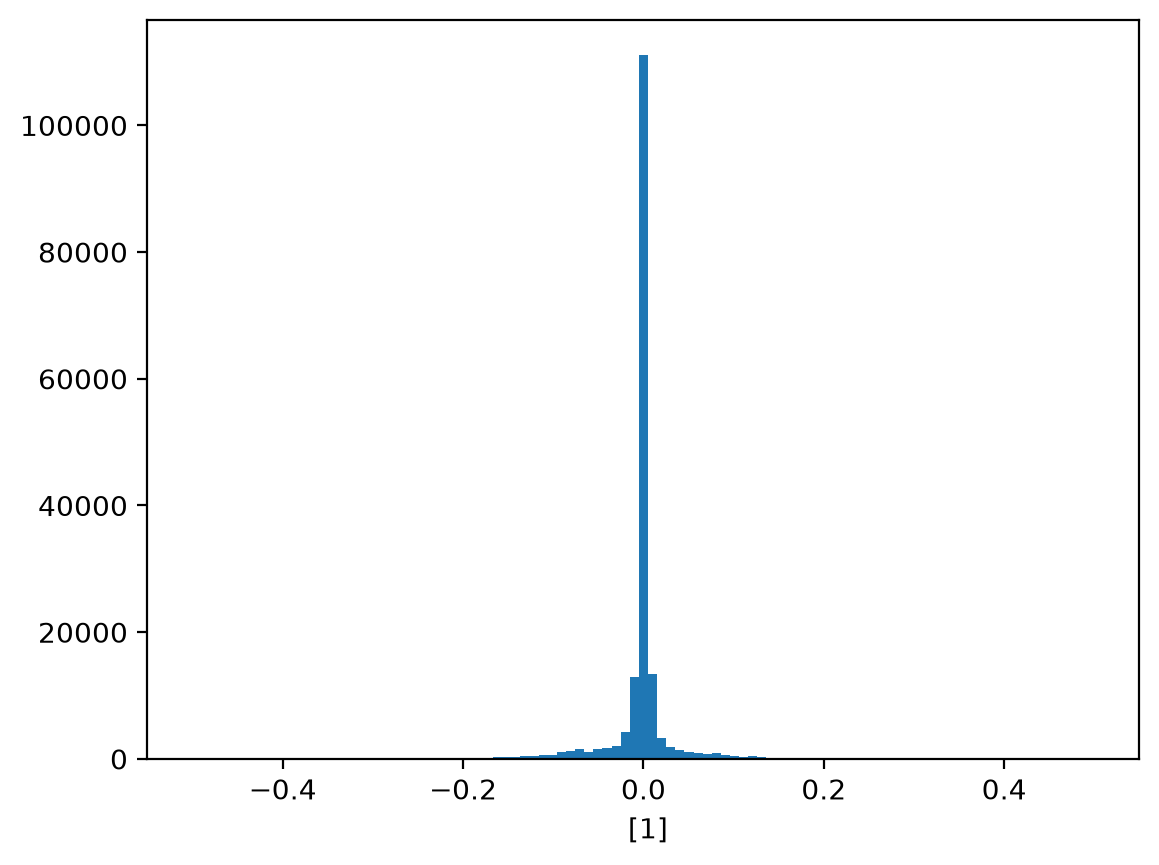

In [40]:
diff.plot.hist(bins = np.linspace(-0.5, 0.5, 100))

In [41]:
adiff = abs(diff).compute()

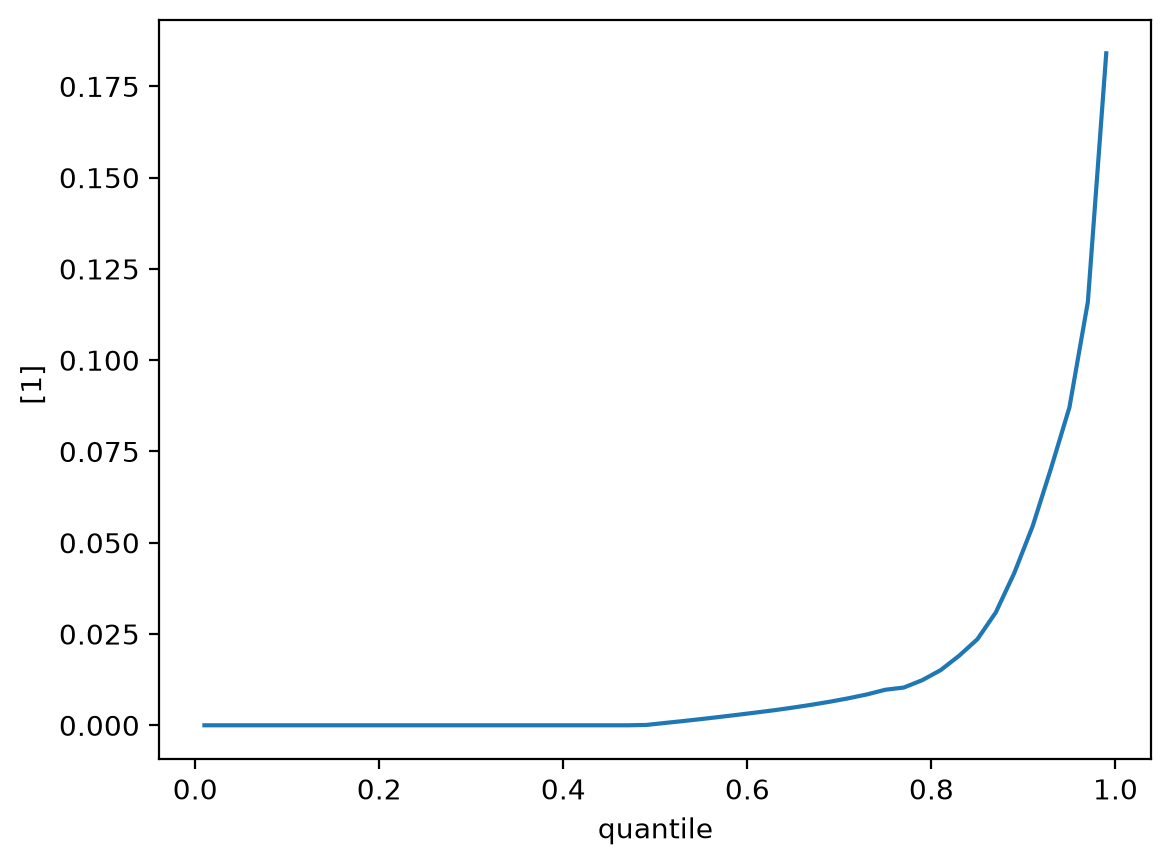

In [42]:
bla = adiff.quantile(np.linspace(0.01,0.99, 50), 'datetime')
bla.plot()

In [43]:
da = adiff
value = 0.1
q = (da <= value).sum() / da.notnull().sum()
q

<xarray.DataArray ()> Size: 8B
array(0.9620521)
Attributes:
    units:        1
    description:  Fractional sky cover retrieved from broadband shortwave rad...

Text(0.5, 1.0, 'sxf')

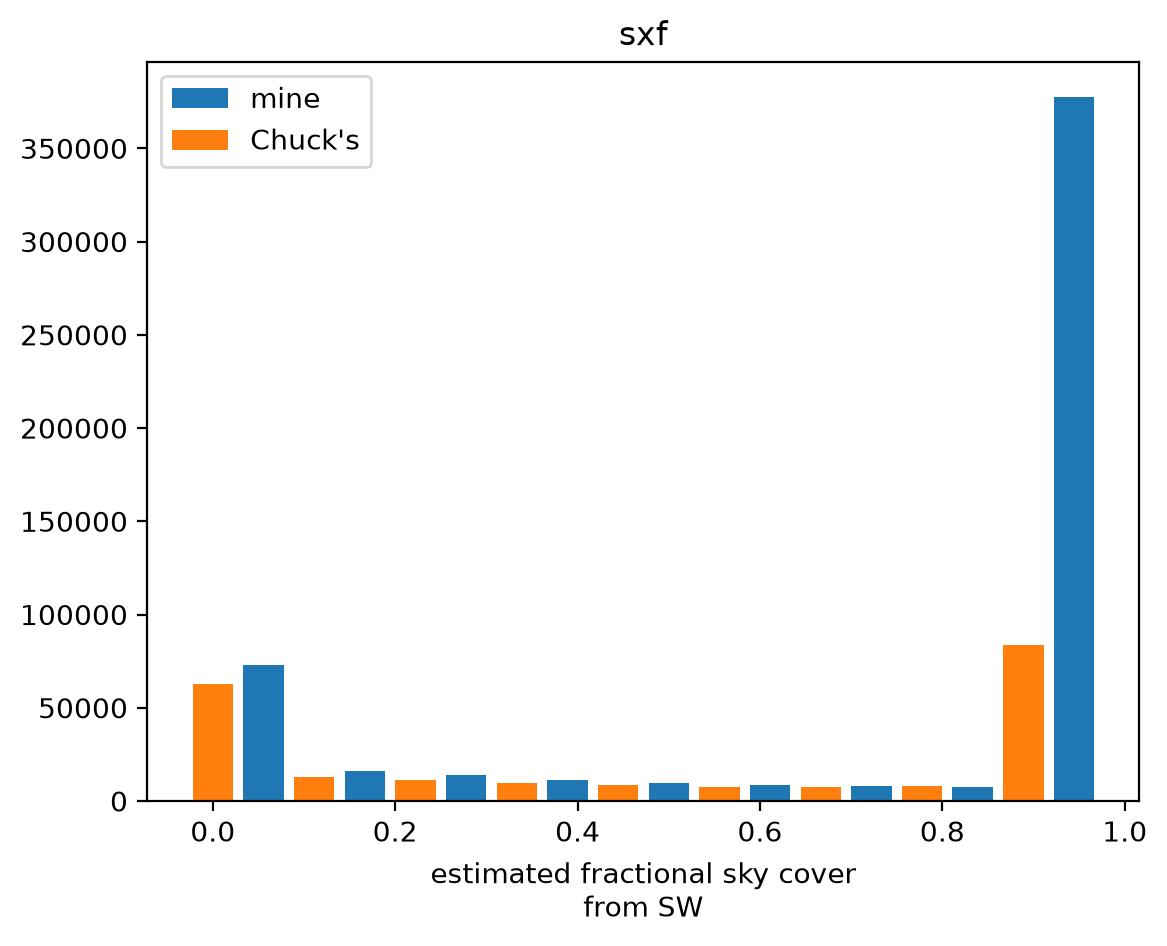

In [44]:
f,a = plt.subplots()
bins = np.linspace(0,1,10)
# db = (bins[1:] - bins[:-1] ).mean()
rw = 0.4
dsrd.shortwave_cloud_fraction.plot.hist(bins = bins, rwidth = rw, label = 'mine', ax = a)
dslri.sky_cover_shortwave.plot.hist(bins =  bins, rwidth = rw, align = 'left', label= "Chuck's", ax= a)
a.legend()
a.set_title(f'{site}')

In [45]:
# where = (dslri.sky_cover_shortwave < 1) & (dslri.sky_cover_shortwave > 0) & (dslri.solar_zenith_angle < szalim)
where = dslri.solar_zenith_angle < szalim
datl = dslri.sky_cover_shortwave.where(where)
                 # - dsrd.clearsky_global_horizontal

# where = (dsrd.shortwave_cloud_fraction < 1) & (dsrd.shortwave_cloud_fraction > 0) & (np.rad2deg(dsrd.solar_zenith) < szalim)
where = np.rad2deg(dsrd.solar_zenith) < szalim

datr = dsrd.shortwave_cloud_fraction.where(where)


Text(0.5, 1.0, 'sxf - za < 70')

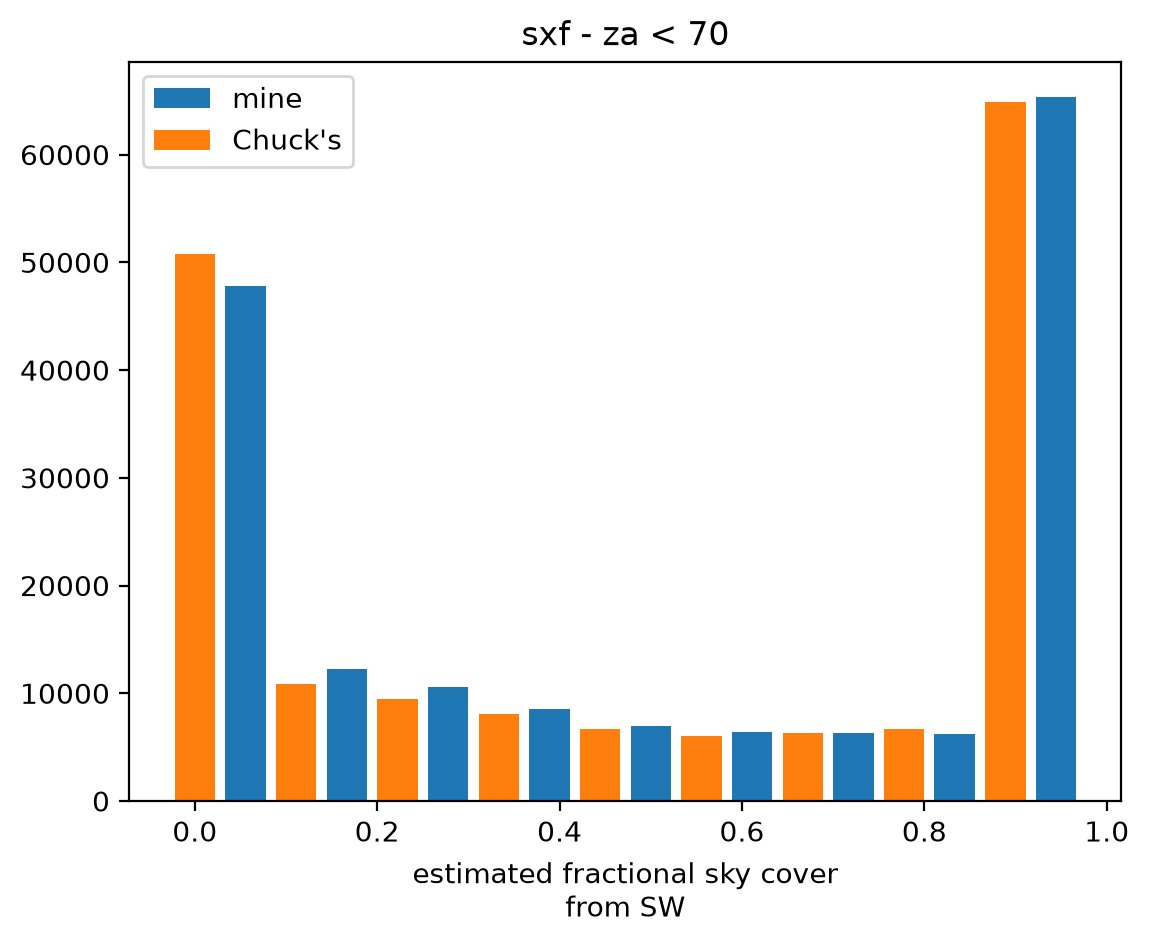

In [46]:
f,a = plt.subplots()
bins = np.linspace(0,1,10)
# db = (bins[1:] - bins[:-1] ).mean()
rw = 0.4
datr.plot.hist(bins = bins, rwidth = rw, label = 'mine', ax = a)
datl.plot.hist(bins =  bins, rwidth = rw, align = 'left', label= "Chuck's", ax= a)
a.legend()
a.set_title(f'{site} - za < 70')